In [56]:
import scipy.special as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [9]:
from bayexpress_functions import get_BF_21, get_FC, get_q, get_BF_k1

from support import (
    prepare_count_matrix,
    sample_overview_data_wrangling,
    gene_ensemble_id_mapping,
)

In [3]:
# setting the priors to flat prios
u_1 = 1
u_2 = 1

In [7]:
METADATA_PATH = f"{os.getcwd()}/../../hgsoc_data_detective/"
DATA_PATH = f"{os.getcwd()}/../../alignment_results/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [10]:
gtf = gene_ensemble_id_mapping(GTF_PATH)
gtf[:5]

[('ENSG00000242021', 'ENSG00000242021'),
 ('ENSG00000182586', 'LINC00334'),
 ('ENSG00000154723', 'ATP5PF'),
 ('ENSG00000133937', 'GSC'),
 ('ENSG00000290659', 'ENSG00000290659')]

In [140]:
DATA_TYPE = "Dissociated Bulk"  # Bulk or Dissociated Bulk

In [141]:
sample_df = sample_overview_data_wrangling(METADATA_PATH, DATA_TYPE)

In [142]:
sample_df.head()

,Site of origin,Long Sample ID
Sample #,,
2018,Omentum,230414/2018
2483,Unknown,230414/2483
2477,Unknown,230414/2477
2460,Omentum,230414/2460
2416,Ovary,230414/2416


In [143]:
count_matrix = prepare_count_matrix(DATA_PATH)

# Select only bulk / diss bulk samples
if DATA_TYPE == "Bulk":
    count_matrix = count_matrix[~count_matrix.index.str.contains("2304")]
elif DATA_TYPE == "Dissociated Bulk":
    count_matrix = count_matrix[count_matrix.index.str.contains("2304")]

# Only consider genes that have more than 10 read counts in total
count_matrix = count_matrix[count_matrix.columns[count_matrix.sum(axis=0) >= 10]]

# Add "site of origin" from sample_df
count_matrix.index.name = "Long Sample ID"
count_df = pd.merge(
    sample_df,
    count_matrix,
    how="inner",
    left_on="Long Sample ID",
    right_on="Long Sample ID",
)
count_df = count_df.set_index("Long Sample ID")

In [144]:
# Only consider ovary and omentum samples
count_df = count_df[
    (count_df["Site of origin"] == "Omentum") | (count_df["Site of origin"] == "Ovary")
]
count_df.rename(columns=dict(gtf), inplace=True)

In [145]:
count_df.head()

,Site of origin,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,ENSG00000291299,PRSS30P,LY6S,TMEM276,ENSG00000291326,ENSG00000291342,ADIPINT,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,426,15,9,47,0,4,1,0,1,2
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,177,117,5,204,0,1,0,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,151,7,0,38,0,0,0,0,6,12
230414/2278,Omentum,557,3,3726,340,209,712,2999,912,480,...,833,158,43,678,1,8,1,1,1,0
230414/2249,Ovary,430,4,1119,311,216,541,3651,1355,308,...,334,18,5,97,0,1,0,0,0,0


In [146]:
omentum_df = count_df[count_df["Site of origin"]=="Omentum"].drop(columns=["Site of origin"]).T

In [147]:
omentum_df

Long Sample ID,230414/2018,230414/2460,230414/2278,230414/2238,230414/2221,230414/2202,230418/2186,230418/2216,230418/2230,230418/2455
TSPAN6,485,499,557,719,814,245,473,779,874,1282
TNMD,1,3,3,1,1,10,3,2,3,3
DPM1,1400,836,3726,1249,1420,1109,760,1175,554,631
SCYL3,86,88,340,367,206,69,98,117,391,183
C1orf112,78,77,209,262,91,60,97,172,149,123
...,...,...,...,...,...,...,...,...,...,...
ENSG00000291342,4,1,8,2,7,1,3,5,14,0
ADIPINT,1,0,1,0,0,0,0,1,0,1
ENSG00000292246,0,0,1,0,0,6,0,0,0,4
ENSG00000292271,1,0,1,1,0,1,0,0,0,0


In [148]:
ovary_df = count_df[count_df["Site of origin"]=="Ovary"].drop(columns=["Site of origin"]).T

In [149]:
ovary_df

Long Sample ID,230414/2416,230414/2249,230414/2129,230414/2526,230418/2423
TSPAN6,466,430,551,515,192
TNMD,11,4,1,0,0
DPM1,402,1119,707,794,605
SCYL3,122,311,134,136,197
C1orf112,79,216,114,73,133
...,...,...,...,...,...
ENSG00000291342,0,1,1,0,0
ADIPINT,0,0,0,0,0
ENSG00000292246,0,0,2,0,1
ENSG00000292271,6,0,0,0,1


In [150]:
# sum of all reads per gene
n_omentum = omentum_df.sum(axis=1)
n_ovary = ovary_df.sum(axis=1)

In [151]:
# sum of all reads
N_omentum = n_omentum.sum()
N_ovary = n_ovary.sum()

In [152]:
N_omentum, N_ovary

(np.int64(192082960), np.int64(74244127))

In [153]:
df = pd.DataFrame(
    {
        "BF_21": get_BF_21(N_omentum, n_omentum, N_ovary, n_ovary),
        "FC": get_FC(N_omentum, n_omentum, N_ovary, n_ovary),
        "BF_k1_omentum": get_BF_k1(omentum_df),
        "BF_k1_ovary": get_BF_k1(ovary_df),
    }
)

In [154]:
df.describe()

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
count,31307.000000,31307.000000,31307.000000,31307.000000
mean,32.367453,0.035257,228.900113,76.329237
std,422.473352,0.967786,2968.045448,843.002278
min,-7.728736,-8.840516,-57.136181,-20.941779
25%,-6.359988,-0.384318,-47.870310,-18.245802
50%,-4.881515,-0.010800,-20.584898,-12.237364
75%,3.313740,0.398982,83.812769,15.305308
max,44411.009980,10.404814,353367.938202,64039.549210


In [155]:
df[df["BF_21"]>1000].sort_values("BF_21", ascending=False)

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
MT-CO1,44411.009980,0.557915,110466.937383,64039.549210
CLU,27915.520865,-1.693487,107504.322185,1138.265942
MT-CO3,18822.650949,0.505998,51289.651229,55672.747068
PLEC,14180.173975,-1.448957,34360.933840,1246.394870
COL1A1,14146.123279,-0.696257,92212.162738,13044.202729
...,...,...,...,...
EMX2OS,1029.913046,-2.189153,1078.334967,35.687485
LAMB3,1029.067570,-1.362049,6478.080729,255.629492
OAS2,1019.888389,1.280729,749.371906,2416.716169
TRIM29,1008.189584,-1.780477,4976.379833,486.475842


In [156]:
df[df.index.str.contains("ADIPOQ")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
ADIPOQ,-6.399156,1.219378,-52.419274,-17.065355


In [163]:
df[df.index.str.contains("PLIN")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
PLIN3,-3.027239,-0.127471,87.108695,3.129360
PLIN2,229.541340,0.621269,1469.648226,990.548153
PLIN1,-6.495687,0.112647,-37.884485,-18.293189
PLIN4,-5.859371,-0.035882,68.650902,18.985653
PLIN5,40.997863,1.084572,-7.506459,163.710188
GAPLINC,-6.700240,0.049453,-44.431293,-17.631006


In [164]:
df[df.index.str.contains("CIDEC")]

,BF_21,FC,BF_k1_omentum,BF_k1_ovary
CIDEC,-5.616374,-1.744097,-48.22482,-19.766243


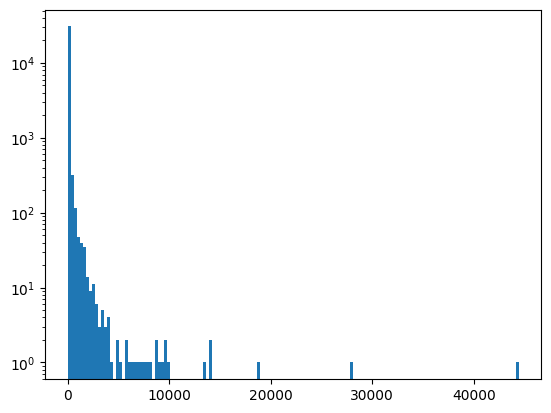

In [157]:

fig, ax = plt.subplots()
ax.hist(df["BF_21"], bins=150)
ax.set_yscale("log")

plt.show()

In [158]:
omentum_q = pd.DataFrame()

for col in omentum_df.columns:
    omentum_q[col] = (omentum_df[col] + 1) / (sum(omentum_df[col])+2)

In [159]:
ovary_q = pd.DataFrame()

for col in ovary_df.columns:
    ovary_q[col] = (ovary_df[col] + 1) / (sum(ovary_df[col])+2)

In [160]:
def q_plot(exp_1, exp_2):

    # printing q-plots
    for t in range(len(exp_1)):
        fig, ax = plt.subplots(figsize=(8, 6))

        # histogram Exp 1
        ax.hist(exp_1.iloc[t], 10, density=False, histtype='step', color='#332288',
                alpha=0.4, orientation='horizontal')

        # histogram Exp 2
        ax.hist(exp_2.iloc[t], 10, density=False, histtype='step', color='#DDCC77',
                alpha=0.4, orientation='horizontal')


        # scatter Exp 1
        ax.scatter(np.arange(1,len(exp_1.columns)+1), exp_1.iloc[t],
                
            c='#332288', s=30, 
            label='Omentum',
            alpha=0.9, edgecolors='none')
        
        # scatter Exp 2
        ax.scatter(np.arange(1,len(exp_2.columns)+1), exp_2.iloc[t],
                
            c='#DDCC77', s=30, 
            label='Ovary',
            alpha=0.9, edgecolors='none')
        
        ax.legend(loc='upper right')

        # Use tex in labels
        ax.set_xticks(np.arange(1,len(exp_1.columns)+1))
        ax.set_xticklabels('')

        # formatting y axis ticks
        plt.gca().ticklabel_format(axis='y', style='plain', useOffset=False)

        ax.set_xlabel('Replicates')
        ax.set_ylabel('q = (n+1) / (N+2)')

        plt.show()

In [161]:
ovary_q[:2]

,230414/2416,230414/2249,230414/2129,230414/2526,230418/2423
TSPAN6,0.000040,2.329129e-05,3.169183e-05,4.913355e-05,1.193353e-05
TNMD,0.000001,2.702006e-07,1.148255e-07,9.522005e-08,6.183178e-08


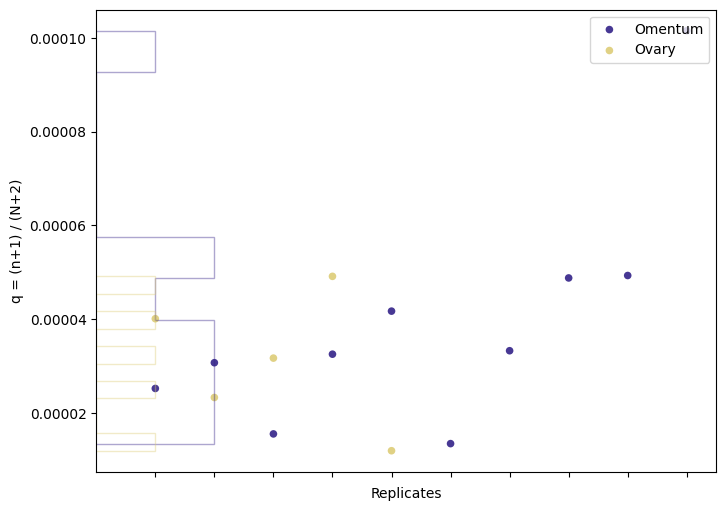

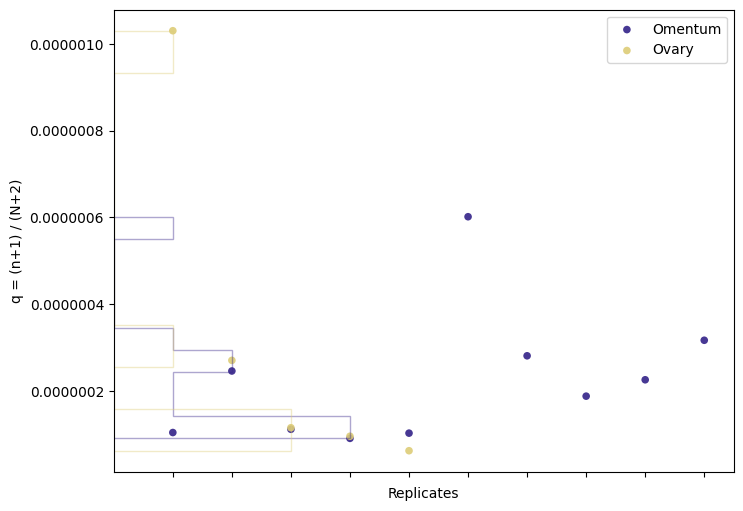

In [162]:
q_plot(omentum_q[:2], ovary_q[:2])

# 